# Computational Essay 
## Topic: Optimierung der Trainingsstrecken für Fahrradfahrer in der Innenstadt 

### I. Beschreibung des realen Problems

Im professionellen Radsport ist gezieltes Training entscheidend für die
Leistungssteigerung. Indoor Trainingsgeräte wie der Wahoo KICKR ermöglicht
es Athleten, strukturierte Workouts unter kontrollierten Bedingungen
durchzuführen. Diese Workouts bestehen aus genau definierten Intervallen, die
vorschreiben, wie lange mit welche Intensität gefahren werden soll.
Während sich solche Trainingseinheiten problemlos in einer Indoor Umgebung
umsetzen lassen, ist die Umsetzung im Freien deutlich komplexer. Draußen
wirken viele unkontrollierbare Faktoren wie Ampeln , Verkehr, Steigung und
Straßenbeschaffenheit. Diese können, dass ein geplanter Trainingsblock
unterbrochen oder ineffektiv wird.
Das reale Problem besteht also darin, eine geeignete reale Radstrecke zu
finden, auf der ein spezifisches Indoor Workout möglichst präzise und ohne
Störungen im Freien absolviert werden kann. Dabei muss die Strecke so
gewählt werden, dass sie zu den Belastungsanforderungen passt, keine oder
möglichst wenige Unterbrechungen aufweist und sicher für den Athleten ist.

#### Forschungsfragen

Die zentralen Forschungsfragen, die wir im Rahmen unseres Projektes
beantworten werden sollen, lauten:

*Wie können wir die Routen Ausgabe optimieren, hinsichtlich den
Workout Vorstellungen des Athleten?* 

*Wie lässt sich das Reale Problem Mathematisch darstellen?*

*Was bedeutet „optimal“ bei einer Trainingsroute, gibt es dabei feste
Regeln oder kommt es auf den Fahrer an?*

*Wie lässt sich die Route so anpassen, dass der Athlet am Ende des
Workouts wieder bei sich Zuhause ankommt?*

### II.Die Daten

Für die Lösung des Problems steht ein Straßennetz der Stadt Bonn als
Datengrundlage zur Verfügung. Diese Daten bilden die reale Umgebung ab, in
der das Outdoor Training stattfinden soll. Das Straßennetz ist als Graph
aufgebaut, bei dem Straßenabschnitte als Kanten und Kreuzungen als Knoten
dargestellt werden.

Enthalte Informationen der Daten
Die Datensätze enthalten unter anderem folgende wichtige Informationen:
- Straßenverbindungen
- Ampelinformationen
- Straßenbeschaffenheit


#### Bedeutung für das Projekt
Diese Informationen sind entscheidend für die Erstellung einer realistischen
und optimalen Trainingsroute. 

Beispiele:
- Glatter Asphalt ohne Ampeln ist ideal für harte Intervallabschnitte, die nicht unterbrochen werden sollen.
- Unbefestigte oder stark befahrende Straßen sollen möglichst vermieden werden.

Die Daten ermöglichen es somit, das Indoor Work-out sinnvoll auf eine reale
Strecke in Bonn zu übertragen, die den Trainingsansanforderungen entspricht
und gleichzeitig praktisch und sicher ist.


#### Graphentheorie und ihre Übertragung auf das Projekt
In der Graphentheorie besteht ein Graph aus Knoten (Punkten) und Kanten (Verbindungen zwischen den Knoten). Man kann sich das so vorstellen: Wenn man per Hand einen Graphen zeichnen möchte, setzt man zunächst einige Punkte auf ein Blatt Papier und verbindet diese anschließend mit Linien.

Es gibt verschiedene Arten von Graphen, vor allem:

**- Ungerichtete Graphen:**
  Hier sind die Verbindungen (Kanten) zwischen den Knoten **ohne feste Richtung**. Das bedeutet, man kann in beide Richtungen zwischen zwei Punkten fahren, wie auf einer normalen Straße ohne Einbahnregelung.

**- Gerichtete Graphen:**
  Bei diesen Graphen haben die Kanten eine **festgelegte Richtung**, z. B. wie Einbahnstraßen im Straßenverkehr, wo man nur in eine Richtung fahren darf.

Der Graph, den wir betrachtet haben, war zunächst **ungerichtet und gewichtet**. Das bedeutet:

- Es gibt **keine festgelegte Richtung** der Verbindungen (man kann eine Straße in beide Richtungen befahren).

- Jede Kante ist mit einem **Gewicht** versehen – in unserem Fall ein sogenannter **„Suitability Score“**, der angibt, wie gut eine Straße für intensives Intervalltraining geeignet ist.

**Übertragung auf unser Projekt**
Im Rahmen unseres Projekts wird das reale Straßennetz von Bonn als Graph dargestellt. Dabei gilt:

- **Knoten** entsprechen den **Kreuzungen oder Abzweigungen** im Straßennetz.

- **Kanten** stellen die **Straßenabschnitte** zwischen den Kreuzungen dar.

Diese abstrakte Darstellung erlaubt es, komplexe Fragestellungen wie „Welche Route erfüllt bestimmte Trainingskriterien am besten?“ mithilfe mathematischer Algorithmen zu lösen. Der Graph bildet also die Grundlage zur Berechnung optimaler Fahrradstrecken, bei denen z. B. Unterbrechungen durch Ampeln minimiert und besonders geeignete Straßenabschnitte für intensive Trainingsintervalle bevorzugt werden.

So wird die reale Stadtstruktur in eine **strukturierte, analysierbare Datenform überführt**, die sich hervorragend für die **automatische Routenplanung und -bewertung** eignet.



### III. Der erste Ansatz

#### Imports
Für die Datenanalyse wird Zugriff auf einige Methoden aus externen
Bibliotheken (= Sammlungen an Methoden, die man anwenden möchte, ohne
sie noch einmal neu zu schreiben). Dazu führen wir im Folgenden einige
Imports durch:

In [23]:
# Import necessary libraries for graph operations, geometry, plotting, randomness, and math
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import random
import math

#### Laden der Daten
Die Daten von der Karte der Stadt Bonn werden in das Jupyter Notebook
geladen. Diese Daten enthalten, wie oben schon gennant, die Vernetzung der
Straßen, die Standorte der Ampeln sowie die Straßenbeschaffenheit im Bezug
auf die Befahrbarkeit für Fahrräder.
Wir lesen die Daten als Graph ein.

Die Funktion `create_graph` erstellt aus einer GeoJSON-Datei ein Straßennetzwerk als NetworkX-Graph. Die Knoten erhalten ihre Geokoordinaten aus den Endpunkten der Linien, die Kanten bekommen eine Länge und eine Qualitätsbewertung. Falls die Qualität nicht im Datensatz enthalten oder unklar ist, wird sie zufällig als "good" oder "medium" vergeben – mit höherer Wahrscheinlichkeit für "good". So entsteht ein strukturierter Graph, in dem jede Verbindung räumlich verortet und inhaltlich bewertet ist. Dieser Graph dient als Grundlage für spätere Routenberechnungen und Visualisierungen.


In [24]:
# Function: Reads a GeoJSON file and constructs a NetworkX graph
# Each edge is given properties like length and a "quality" label (good, bad, or medium)
def create_graph(edges_file):
    edges = gpd.read_file(edges_file)
    G = nx.Graph()

    for _, row in edges.iterrows():
        geom = row.geometry
        if geom is None or geom.geom_type != "LineString":
            continue

        u_coords = geom.coords[0]
        v_coords = geom.coords[-1]
        u = row["u"]
        v = row["v"]

        G.add_node(u, x=u_coords[0], y=u_coords[1])
        G.add_node(v, x=v_coords[0], y=v_coords[1])

        length = row.get("length", geom.length)

        raw_quality = row.get("quality", "")
        if isinstance(raw_quality, str):
            raw_quality = raw_quality.strip().lower()
        else:
            raw_quality = ""

        if raw_quality == "good":
            quality = "good"
        elif raw_quality == "bad":
            quality = "bad"
        else:
            #Randomly assign medium or good with bias toward good
            quality = random.choices(["good", "medium"], weights=[0.7, 0.3])[0]

        G.add_edge(u, v, length=length, geometry=geom, quality=quality)

    return G


Die Funktion `edge_straightness` berechnet, wie „gerade“ ein Straßenabschnitt ist, basierend auf seinem Linienverlauf (`LineString`). Dafür wird die tatsächliche Länge der Linie durch die direkte Luftlinienentfernung zwischen Start- und Endpunkt geteilt. Ein Wert nahe 1 bedeutet, dass der Abschnitt sehr gerade ist; je größer der Wert, desto kurviger ist die Strecke. Bei einer direkten Verbindung ohne Kurven wären Länge und Distanz nahezu gleich. Die Funktion hilft später dabei, gezielt gerade Strecken für Intervalle auszuwählen.


In [25]:
# Function: Measures how straight a street segment is
# A value near 1 means straight, higher values mean curvy
def edge_straightness(geom):
    if geom is None:
        return 1
    coords = list(geom.coords)
    length = geom.length
    start = coords[0]
    end = coords[-1]
    direct_dist = math.dist(start, end)
    if direct_dist == 0:
        return 1
    return length / direct_dist

Die Funktion `plot_route` visualisiert eine gegebene Route innerhalb des Straßennetzwerks und hebt dabei unterschiedliche Streckenabschnitte farblich hervor. Zuerst wird die gesamte Route in Intervalle und Erholungsabschnitte unterteilt, wobei nur gerade Strecken (geringer Kurvenfaktor) als Intervalle zulässig sind. Die Länge jedes Intervalls bzw. Erholungssegments ergibt sich aus der Gesamtstrecke geteilt durch die doppelte Anzahl der gewünschten Intervalle. Anschließend werden die einzelnen Straßenkanten analysiert und zu Segmenten gruppiert. Im Plot werden alle Straßen im Hintergrund grau dargestellt, während Intervalle in Blau erscheinen. Erholungssegmente werden je nach Qualität grün („good“), gold („medium“) oder grau („bad“) gefärbt. Der Startpunkt der Route wird zusätzlich rot markiert.


In [26]:
# Function: Plots a given route on top of the street network
# Highlights intervals and recovery segments in different colors
def plot_route(G, path, num_intervals=None):
    pos = {n: (data["x"], data["y"]) for n, data in G.nodes(data=True)}
    edge_path = list(zip(path, path[1:]))

    total_length = sum(G[u][v]['length'] for u, v in edge_path)
    if num_intervals is None or num_intervals < 1:
        num_intervals = 1

    segment_length = total_length / (2 * num_intervals)
    threshold_straightness = 1.10  # max curve allowed for interval

    segments = []
    current_coords = []
    current_length = 0
    current_is_interval = True

    idx = 0
    while idx < len(edge_path):
        u, v = edge_path[idx]
        geom = G[u][v].get("geometry")
        quality = G[u][v].get("quality", "medium")
        coords = list(geom.coords) if geom else [pos[u], pos[v]]
        edge_len = G[u][v]['length']
        straightness = edge_straightness(geom)

        # Group edges into segments depending on whether they're part of an interval
        if current_is_interval and straightness <= threshold_straightness:
            if current_length + edge_len <= segment_length + 1e-6:
                if not current_coords:
                    current_coords.append(coords[0])
                current_coords.extend(coords[1:])
                current_length += edge_len
                idx += 1
            else:
                segments.append((current_coords, current_is_interval, quality))
                current_coords = []
                current_length = 0
                current_is_interval = not current_is_interval
        else:
            if not current_coords:
                current_coords.append(coords[0])
            current_coords.extend(coords[1:])
            current_length += edge_len
            idx += 1

            if current_length >= segment_length - 1e-6:
                segments.append((current_coords, current_is_interval, quality))
                current_coords = []
                current_length = 0
                current_is_interval = not current_is_interval

    if len(current_coords) > 1:
        segments.append((current_coords, current_is_interval, quality))

    plt.figure(figsize=(10, 10))

    # Draw all streets as light gray background
    for u, v, data in G.edges(data=True):
        geom = data.get("geometry")
        if geom is not None:
            xs, ys = zip(*list(geom.coords))
            plt.plot(xs, ys, color="lightgray", linewidth=1)
        else:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            plt.plot([x1, x2], [y1, y2], color="lightgray", linewidth=1)

    # Draw the route segments
    for coords, is_interval, quality in segments:
        xs, ys = zip(*coords)
        if is_interval:
            color = "blue"  # interval
        else:
            if quality == "good":
                color = "green"
            elif quality == "medium":
                color = "gold"
            else:
                color = "gray"
        plt.plot(xs, ys, color=color, linewidth=4)

    # Highlight start node in red
    nx.draw_networkx_nodes(G, pos, nodelist=[path[0]], node_color="red", node_size=100)

    plt.axis("off")
    plt.title("Route with Intervals (blue), Quality Sections (green/yellow/gray), Start (red)")
    plt.show()

Die Funktion `get_local_subgraph` erzeugt einen lokalen Teilgraphen (Subgraph) rund um einen gegebenen Startknoten. Mithilfe von Dijkstras Algorithmus werden alle Knoten bestimmt, die innerhalb einer bestimmten maximalen Distanz (in Metern) vom Startpunkt aus erreichbar sind. Diese Knoten und die zugehörigen Kanten werden extrahiert und zu einem neuen Graphenobjekt zusammengesetzt. Dieser Subgraph bildet somit das unmittelbare Umfeld des Startpunkts und dient als Grundlage für weitere Analysen, zum Beispiel zur Suche nach lokalen Rundrouten. Die Anzahl der enthaltenen Knoten und Kanten wird zur Kontrolle in der Konsole ausgegeben.


In [27]:
# Function: Extracts a local subgraph around a node with a maximum distance
def get_local_subgraph(G, start_node, max_distance):
    lengths = nx.single_source_dijkstra_path_length(G, start_node, cutoff=max_distance, weight='length')
    reachable_nodes = set(lengths.keys())
    subgraph = G.subgraph(reachable_nodes).copy()
    print(f"Subgraph: {len(subgraph.nodes)} nodes, {len(subgraph.edges)} edges (Radius: {max_distance:.1f} m)")
    return subgraph

Die Funktion `find_multiple_circular_routes` sucht im Straßennetzwerk nach bis zu `max_routes` Rundrouten, die am gegebenen Startknoten beginnen und enden und in ihrer Gesamtlänge möglichst nah an einem Zielwert (`target_length`) liegen. Dazu wird das Netzwerk rund um den Startknoten mehrfach in unterschiedlich großen Radien betrachtet, um die Chancen auf passende Zyklen zu erhöhen. Innerhalb jedes Teilgraphen werden alle einfachen Zyklen ermittelt, die den Startpunkt enthalten. Die Länge dieser Zyklen wird berechnet, und nur solche, deren Länge innerhalb einer tolerierten Abweichung zum Zielwert liegt, werden berücksichtigt. Um Dopplungen zu vermeiden, werden nur eindeutig unterschiedliche Routen gespeichert. Die Suche endet, sobald die gewünschte Anzahl an Rundrouten gefunden wurde oder alle Optionen ausgeschöpft sind.


In [28]:
# Function: Find up to N circular routes that start and end at a node and are close to a target length
def find_multiple_circular_routes(G, start_node, target_length, tolerance_ratio=0.8, max_routes=3):
    print("Searching for multiple circular routes...")

    # Helper: All simple cycles containing the start node
    def get_cycles(subgraph):
        return [c for c in nx.cycle_basis(subgraph) if start_node in c]

    # Helper: Calculate total length of a cycle
    def cycle_length(cycle, subgraph):
        cycle = cycle + [cycle[0]]
        length = 0
        for u, v in zip(cycle[:-1], cycle[1:]):
            if subgraph.has_edge(u, v):
                length += subgraph[u][v]['length']
            else:
                return float('inf')
        return length

    found_routes = []
    # Vary search radius and tolerance to broaden possibilities
    search_radii = [target_length * 1.5, target_length * 2.5, target_length * 3.5]
    tolerances = [tolerance_ratio, tolerance_ratio * 1.5, tolerance_ratio * 2]

    for radius, tol in zip(search_radii, tolerances):
        subgraph = get_local_subgraph(G, start_node, radius)
        cycles = get_cycles(subgraph)
        for cycle in cycles:
            start_idx = cycle.index(start_node)
            cycle = cycle[start_idx:] + cycle[:start_idx] + [start_node]

            length = cycle_length(cycle[:-1], subgraph)

            if length < target_length * 0.4:
                continue
            if abs(length - target_length) <= target_length * tol:
                # Avoid duplicate cycles
                if any(set(route) == set(cycle) for route in found_routes):
                    continue
                found_routes.append(cycle)
                if len(found_routes) >= max_routes:
                    break
        if len(found_routes) >= max_routes:
            break

    if found_routes:
        print(f"{len(found_routes)} suitable circular routes found.")
    else:
        print("❌ No suitable circular route found.")

    return found_routes

Die `main`-Funktion bildet den interaktiven Einstiegspunkt des Programms. Zunächst wird eine GeoJSON-Datei eingelesen und daraus ein Graph konstruiert, der Straßen als Kanten und Kreuzungen als Knoten darstellt. Anschließend werden vom Benutzer drei Angaben abgefragt: ein Startknoten (als Ganzzahl), die gewünschte Gesamtlänge der Rundroute (in Metern) und die Anzahl der Intervallabschnitte (z. B. für Trainingsintervalle). Nach Validierung der Eingaben sucht das Programm mithilfe der zuvor definierten Logik nach geeigneten Rundrouten, die diese Kriterien erfüllen. Für jede gefundene Route wird der Verlauf zusammen mit farblicher Hervorhebung der Intervalle und Abschnitte unterschiedlicher Straßenqualität grafisch dargestellt. Falls keine passende Route gefunden wurde, gibt das Programm eine entsprechende Meldung aus.


Enter start node (number):  1612637229
Desired route length in meters:  50000
Number of desired interval segments:  8


Searching for multiple circular routes...
Subgraph: 6594 nodes, 9243 edges (Radius: 75000.0 m)
Subgraph: 6594 nodes, 9243 edges (Radius: 125000.0 m)
Subgraph: 6594 nodes, 9243 edges (Radius: 175000.0 m)
3 suitable circular routes found.
Route 1: [1612637229, 1612637227, 1612637213, 1612637211, 268891631, 268891276, 2601648593, 268891258, 268891252, 2394163865, 31475863, 264391670, 983570811, 983570850, 983570846, 983570939, 983570873, 983570807, 310291350, 310291352, 264391481, 2304054498, 1626361180, 31475901, 4096447292, 4096447291, 248111682, 294232173, 1227968047, 1227967861, 2394850296, 2394850288, 2297369346, 1232186589, 2483382934, 2202413121, 244636468, 245038403, 322794869, 296181901, 943960868, 943912516, 943836911, 943836783, 943865037, 943836863, 296181321, 296181308, 296181112, 245038426, 948340999, 295681814, 529002049, 270292727, 245038430, 268326236, 3065484825, 3065484818, 312996223, 312998828, 312998827, 312996234, 312996233, 1516408897, 372503662, 371513853, 37151384

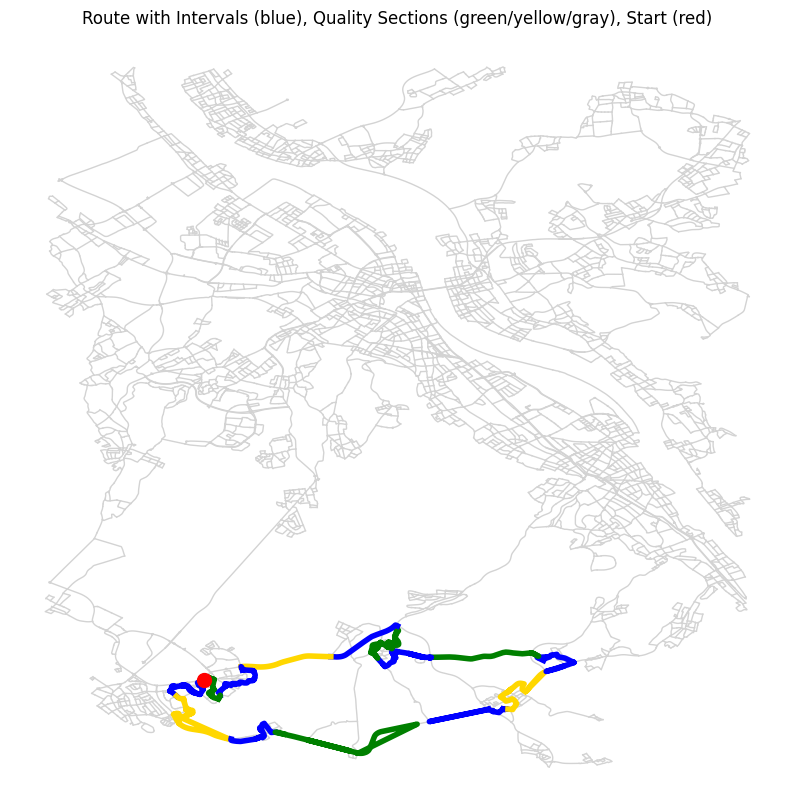

Route 2: [1612637229, 1612637227, 1612637213, 1612637211, 268891631, 268891276, 2601648593, 268891258, 268891252, 2394163865, 31475863, 264391670, 983570811, 983570850, 983570846, 983570939, 983570873, 983570807, 310291350, 310291352, 264391481, 2304054498, 1626361180, 31475901, 4096447292, 4096447291, 248111682, 294232173, 1227968047, 1227967861, 2394850296, 2394850288, 2297369346, 1232186589, 2483382934, 2202413121, 2394850319, 31475885, 288657073, 288657074, 2296963183, 2296963383, 1154629444, 2296963695, 2296963801, 2297008871, 288657086, 297046029, 297067716, 297050410, 2312857315, 2312857268, 2312857214, 297050408, 297040805, 3857700959, 297040802, 440648206, 34580760, 2305540251, 2290231553, 27000964, 760456330, 2290277531, 760456292, 760456277, 246344044, 945018541, 2185869875, 2185869880, 2185869884, 27135417, 245053481, 245053467, 2429865705, 2429865716, 27560742, 249613177, 249613193, 249613178, 27135441, 672177410, 27135404, 27135440, 27135403, 2429865732, 27135398, 1426497

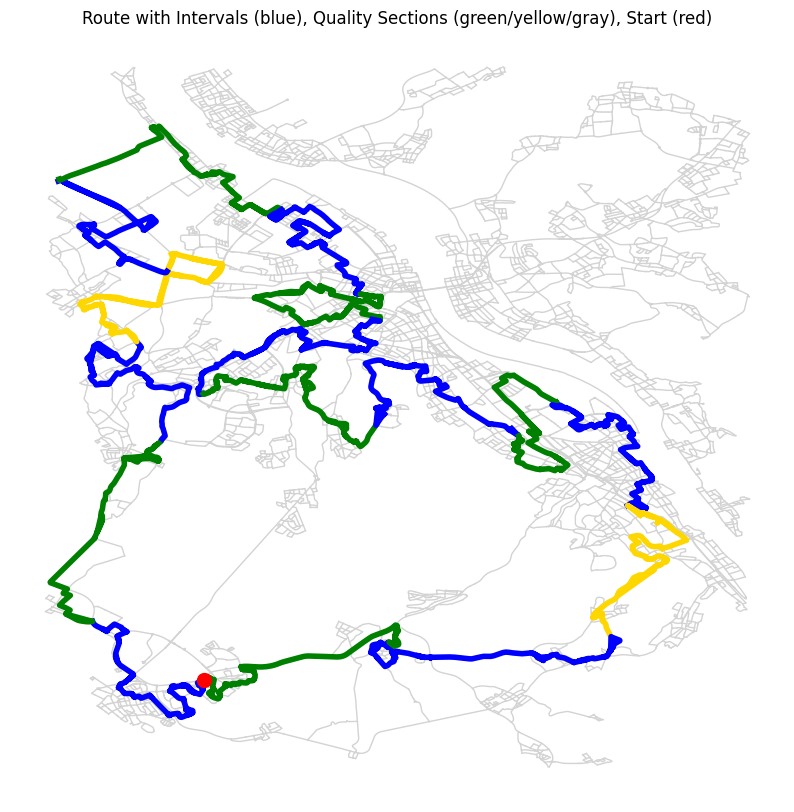

Route 3: [1612637229, 1612637227, 1612637213, 1612637211, 268891631, 268891276, 2601648593, 268891258, 268891252, 2394163865, 31475863, 264391670, 983570811, 983570850, 983570846, 983570939, 983570873, 983570807, 310291350, 310291352, 264391481, 2304054498, 1626361180, 31475901, 4096447292, 4096447291, 248111682, 294232173, 1227968047, 1227967861, 2394850296, 2394850288, 2297369346, 1232186589, 2483382934, 2202413121, 2394850319, 31475885, 288657073, 288657074, 2296963183, 2296963383, 1154629444, 2296963695, 2296963801, 2297008871, 288657086, 297046029, 297067716, 297050410, 2312857315, 2312857268, 2312857214, 297050408, 297040805, 3857700959, 297040802, 440648206, 34580760, 2305540251, 2290231553, 27000964, 760456330, 2290277531, 760456292, 760456277, 246344044, 945018541, 2185869875, 2185869880, 2185869884, 27135417, 245053481, 245053467, 2429865705, 2429865716, 27560742, 249613177, 249613193, 249613178, 27135441, 672177410, 27135404, 27135440, 27135403, 2429865732, 27135398, 1426497

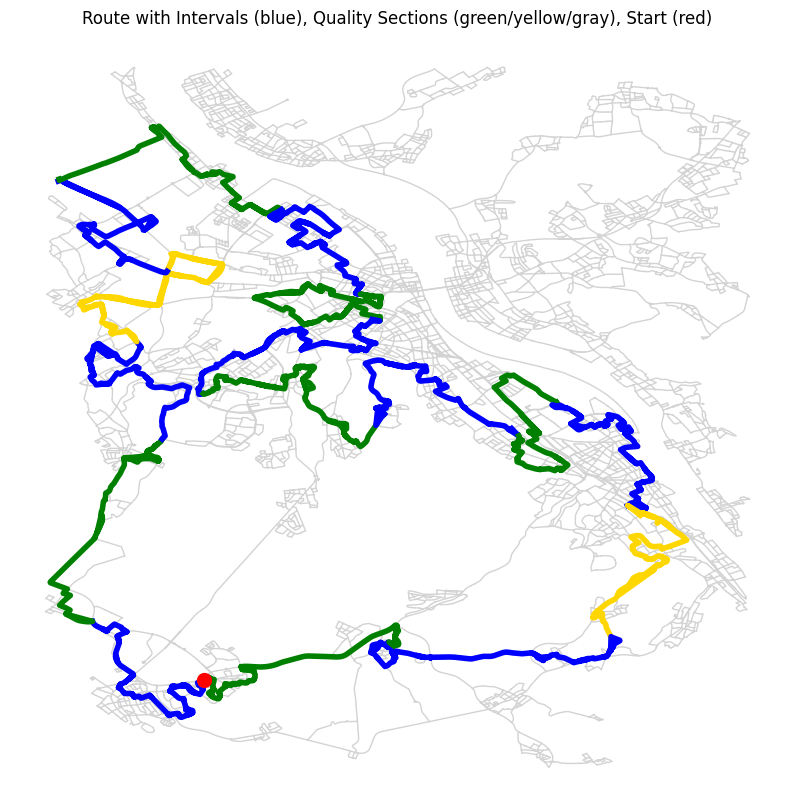

In [29]:
# Main Function: Runs the interactive program
# - Loads graph
# - Asks for user input
# - Searches for circular routes
# - Plots the result

def main():
    edges_file = "../../data/streets_between_junctions.geojson"
    G = create_graph(edges_file)

    try:
        start_node = int(input("Enter start node (number): "))
    except ValueError:
        print("Invalid input for start node. Please enter a number.")
        return
    if start_node not in G.nodes:
        print(f"Start node {start_node} is not in the graph.")
        return

    try:
        target_length = float(input("Desired route length in meters: "))
    except ValueError:
        print("Invalid input for route length. Please enter a number.")
        return

    try:
        num_intervals = int(input("Number of desired interval segments: "))
        if num_intervals < 1:
            print("Number of intervals must be at least 1.")
            return
    except ValueError:
        print("Invalid input for number of intervals. Please enter a number.")
        return

    routes = find_multiple_circular_routes(G, start_node, target_length)

    if routes:
        for i, route in enumerate(routes, 1):
            print(f"Route {i}: {route}")
            plot_route(G, route, num_intervals=num_intervals)
    else:
        print("No routes found to display.")

if __name__ == "__main__":
    main()

Wenn der Code ausgeführt wird, werden sowohl die Knotenpunkte ausgegeben, über welche man die Route nachvollziehen kann, als auch eine Abbildung der Route im Straßennetz. Die blau markierten Strecken stellen dabei die hochintensiven Intervalle dar. Auf diesen Intervallen ist die Straßenqualität stets "good" mit vereinzelnten Außnahmen, die die Straßenqualität "medium" aufweisen. Die grünen Abschnitte haben ebenfalls auch noch Straßenqualität "good", also das Beste. Die gelben Abschnitte weisen Straßenqualität "medium" auf. Die (seltenen) roten Abschnitte haben Straßenqualität "bad". 

 ### IV. Der zweite Ansatz

#### Importe
Für die Datenanalyse wird Zugriff auf einige Methoden aus externen Bibliotheken benötigt (= Sammlungen an Methoden, die man anwenden möchte, ohne sie neu zu programmieren). Dazu führen wir im Folgenden einige Imports durch:

In [30]:
# === Imports ===
import networkx as nx                    # For creating and analyzing graphs
from utils.create_graph import create_graph  # Custom function to load a graph from GeoJSON data
from utils.logger import logger              # Custom logger (for structured logging, if used)
from itertools import islice             # To limit the number of paths considered
import webbrowser                        # Used to open the saved HTML map in the browser
import folium                            # For creating interactive leaflet-based maps

#### Main Function
Die Funktion main() dient als zentraler Einstiegspunkt zur Erstellung des Wegenetzes in Form eines Graphen. Dafür verwendet sie GeoJSON-Dateien, in denen Straßenverbindungen, Ampeln und Stoppschilder gespeichert sind.

In [31]:
# === Main function to build the graph ===
def main(
    edges_file: str = "../../data/streets_between_junctions.geojson",  # Street connections
    signals_file: str = "../../data/traffic_signals.geojson",          # Locations of traffic signals
    stops_file: str = "../../data/stop_signs.geojson",                 # Locations of stop signs
    n: int = 5,                                                        # Number of sample edges to log
):
    # Create the graph from the given files
    G = create_graph(
        edges_file=edges_file,
        signals_file=signals_file,
        stops_file=stops_file,
    )


    return G    # Return the generated graph

#### Speed Parsing Helper
In den Quelldaten können Geschwindigkeitsangaben in unterschiedlichen Formaten vorliegen – entweder als ganze Zahl (int) oder als Text (str, z. B. "50 km/h"). Damit diese Daten einheitlich weiterverwendet werden können, brauchen wir eine Hilfsfunktion zur Vereinheitlichung.

In [32]:
# === Speed Parsing Helper ===
# Extracts and standardizes speed limit values from mixed input formats (int/str)
def parse_speed(speed):
    if isinstance(speed, int):
        return speed
    if isinstance(speed, str):
        digits = ''.join(filter(str.isdigit, speed))    # Extract digits from the string
        if digits:
            return int(digits)
    return 30  # Default fallback speed if input is missing or invalid

#### Bike-Friendliness Cost Function
Um bewerten zu können, wie gut eine Straße für Fahrradfahrende geeignet ist, wird eine sogenannte "Kostenfunktion" verwendet. Diese Funktion berechnet einen Wert dafür, wie fahrradfreundlich eine Strecke ist – je niedriger der Wert, desto besser.

Die Funktion calculate_suitability_cost(speedlimit, smoothness) berücksichtigt zwei Hauptfaktoren:

1. Geschwindigkeit (Speed Score)
   Zuerst wird mit der Hilfsfunktion parse_speed sichergestellt, dass die Geschwindigkeitsangabe einheitlich interpretiert wird. Anschließend     wird bewertet:

   Je höher das Tempolimit, desto besser ist die Straße für Radfahrende – z. B. weil sie eher eine Hauptstraße ist.

   Spielstraßen oder Zonen mit sehr niedriger Geschwindigkeit gelten als weniger geeignet, da sie evtl. häufig blockiert oder schlecht       ausgebaut sind.

2. Straßenzustand (Smoothness Score)
   Es wird geprüft, wie gut der Straßenbelag ist. Dafür gibt es vordefinierte Kategorien wie "excellent", "bad" oder "impassable". Je     schlechter der Belag, desto höher der Wert – was die Straße unattraktiver fürs Radfahren macht.

    Kombination beider Faktoren
    Der endgültige "Unfreundlichkeitswert" wird als Kombination aus Geschwindigkeit (zu 60 %) und Oberflächenqualität (zu 40 %) berechnet.

Dieser Wert wird später bei der Auswahl von Routen verwendet – je niedriger, desto besser die Strecke für Radfahrende.

In [33]:
# === Bike-Friendliness Cost Function ===
# Computes a cost representing how suitable a street is for biking, based on speed and surface quality
def calculate_suitability_cost(speedlimit, smoothness): 
    
    # Speed score: lower is better
    speed_limit = parse_speed(speedlimit)

    # Speed score: lower is more bike-friendly
    if speed_limit >= 50:
        speed_score = 0  # Most suitable
    elif speed_limit >= 40:
        speed_score = 0.5  # Good
    elif speed_limit >= 30:
        speed_score = 1  # Acceptable
    else:
        speed_score = 2  # Least suitable (e.g. play streets or pedestrian zones)

    # Smoothness: road surface quality (lower is better)
    smoothness_ratings = {
        "excellent": 0,
        "good": 0.5,
        "intermediate": 1,
        "bad": 2,  
        "very_bad": 3,
        "horrible": 4,
        "very_horrible": 5,
        "impassable": 10
    }
    smoothness_score = smoothness_ratings.get(smoothness.lower(), 3)  # Default:"bad"

    # Weighted combination of both factors
    cost = 0.6 * speed_score + 0.4 * smoothness_score
    return cost

#### Annotate Graph Edges with Bike Scores
Damit später möglichst fahrradfreundliche Routen gefunden werden können, weist diese Funktion (add_edge_scores(G)) jeder Straßenverbindung im Graphen eine Bewertung zu.

Für jede Verbindung (Kante) im Netzwerk wird:

1. Die zulässige Höchstgeschwindigkeit (maxspeed) ermittelt – falls diese Information fehlt, wird der Standardwert 30 km/h verwendet.

2. Die Straßenbeschaffenheit (smoothness) ausgelesen. Dieser Wert beschreibt die Oberflächenqualität der Straße, zum Beispiel „excellent“, „good“ oder „bad“. Falls kein Wert vorhanden ist, wird „bad“ als Standard angenommen.

Diese beiden Merkmale werden in der Funktion calculate_suitability_cost kombiniert, um einen Fahrradtauglichkeitswert (bike_score) zu berechnen. Je niedriger der Wert, desto besser ist die Straße fürs Fahrradfahren geeignet.

Der bike_score wird anschließend als neues Attribut an die jeweilige Kante im Graphen angehängt.

In [34]:
# === Annotate Graph Edges with Bike Scores ===
# Annotates each edge in the graph with a calculated 'bike_score' for later route optimization
def add_edge_scores(G):
    for u, v, data in G.edges(data=True):
        speedlimit = data.get("maxspeed", 30)   
        smoothness = data.get("smoothness", 3)

        bike_score = calculate_suitability_cost(speedlimit,smoothness)

        data["bike_score"] = bike_score # Store the result in the edge's attributes

#### Route Interval Validation
In diesem Abschnitt überprüfen wir, ob eine vorgeschlagene Route abwechselnd aus intensiven und erholsamen Intervallen besteht – so wie es für Intervalltraining sinnvoll ist. Dabei soll jedes Intervall eine bestimmte Länge haben und bestimmte Qualitätsansprüche erfüllen.

Die Funktion is_variable_interval_route_fixed_lengths prüft also:

- ob sich die Abschnitte regelmäßig abwechseln (intensiv → entspannend → intensiv …),

- ob die Längen der einzelnen Intervalle mit den Vorgaben (z. B. 90 m intensiv, 150 m Erholung) ungefähr übereinstimmen,

- und ob die Qualität der Strecke in den intensiven Abschnitten gut genug ist (gemessen über den bike_score).

Dazu wird die Route (bestehend aus mehreren Wegpunkten) Schritt für Schritt analysiert:

1. Es wird je ein Abschnitt mit der Ziel-Länge zusammengesetzt – entweder intensiv oder entspannend.

2. Die mittlere Fahrradfreundlichkeit des Abschnitts wird berechnet.

3. Falls ein intensiver Abschnitt nicht fahrradfreundlich genug ist (d. h. der Durchschnittswert ist höher als der erlaubte Schwellenwert), wird die Route verworfen.

4. Wenn alle Abschnitte zur gewünschten Struktur passen, wird die Route als gültig eingestuft.

Diese Funktion ist zentral für das spätere Filtern von geeigneten Intervallrouten.

In [35]:
# === Route Interval Validation ===
def is_variable_interval_route_fixed_lengths(
    G,
    path,
    intensive_lengths,
    relax_lengths,
    threshold=1.2
):

    """
Validates if a route alternates between 'intensive' and 'relaxation' intervals, 
each meeting length targets and staying within a maximum bike_score threshold.
"""

    i = 0
    i = 0
    n = len(path) - 1
    mode = "intensive" 
    intensive_idx = 0
    relax_idx = 0

   
    while i < n:
       if mode == "intensive":
            if intensive_idx >= len(intensive_lengths):
                break
            target_length = intensive_lengths[intensive_idx]
            intensive_idx += 1
       else:
            if relax_idx >= len(relax_lengths):
                
                break
            target_length = relax_lengths[relax_idx]
            relax_idx += 1
        
       segment = []
       current_len = 0
        
         # Collect edges until target length is met
       while i < n and current_len < target_length:
            u, v = path[i], path[i + 1]
            edge_len = G[u][v]["length"]
            segment.append((u, v))
            current_len += edge_len
            i += 1
        
       if current_len == 0:
            continue
        
       # Compute average bike score
       total_score = sum(G[u][v].get("bike_score", 1) * G[u][v]["length"] for u, v in segment)
       avg_score = total_score / current_len

       if mode == "intensive" and avg_score > threshold:
            # Too poor for intensive segment
            return False

       mode = "relax" if mode == "intensive" else "intensive"

    # All intervals were acceptable
    return True

#### Find All Loop Candidates Around a Node
Diese Funktion sucht innerhalb des Graphen nach möglichen Rundwegen (Loops), die an einem bestimmten Startknoten beginnen und enden.

Die Suche ist begrenzt durch:

- eine minimale und maximale Gesamtlänge des Rundwegs,

- sowie eine maximale Tiefe (maximale Anzahl der Knoten im Pfad), um die Suche nicht zu unendlich auszudehnen.

Dabei arbeitet die Funktion so:

- Mit Hilfe einer Tiefensuche (Depth-First Search, DFS) werden mögliche Wege erkundet.

- Jeder Weg wird erweitert, solange er die maximale Länge und maximale Tiefe nicht überschreitet.

- Findet sie einen Weg, der zum Startknoten zurückführt und die Längenbedingung erfüllt, wird dieser als Rundweg-Kandidat gespeichert.

- Am Ende gibt die Funktion alle gefundenen Rundwege aus, die in die vorgegebenen Längen passen.

Praktisch hilft diese Funktion dabei, alle möglichen geeigneten Schleifen für die Routenplanung zu identifizieren.

In [36]:
# === Find All Loop Candidates Around a Node ===
    # Performs a bounded DFS to find loop candidates from a start node within length constraints
def find_loop_candidates(G, start_node, min_length, max_length, max_depth=17):
    """Find loop paths starting and ending at start_node within a length range."""
    candidates = []
    stack = [(start_node, [start_node], 0)]  # (current_node, path, current_length)

    while stack:
        current, path, total_length = stack.pop()

        if len(path) > max_depth:
            continue

        for neighbor in G.neighbors(current):
            if neighbor == start_node and len(path) > 2:
                loop_length = total_length + G[current][neighbor]["length"]
                if min_length <= loop_length <= max_length:
                    candidates.append((path + [start_node], loop_length))
            elif neighbor not in path:  
                edge_length = G[current][neighbor]["length"]
                if total_length + edge_length <= max_length:
                    stack.append((neighbor, path + [neighbor], total_length + edge_length))
    print(f">>> {len(candidates)} Loop-Kandidaten gefunden.")

    return candidates

#### Main Search Function for Best Loop
Diese Funktion sucht den besten Rundweg (Loop) im Graphen ausgehend von einem Startknoten. Dabei berücksichtigt sie:

- dass der Rundweg eine Länge zwischen einem Minimum und Maximum haben muss,

- dass sich intensive (anstrengende) und entspannte Abschnitte im vorgegebenen Wechsel (Längen) abwechseln,

- und dass die durchschnittliche „Fahrradfreundlichkeit“ (bike_score) möglichst niedrig sein soll – also der Weg möglichst angenehm zum Fahrradfahren.

So funktioniert die Suche:

- Die Funktion erweitert schrittweise den Suchradius um den Startknoten, um alle erreichbaren Knoten in diesem Radius zu finden.

- Für jeden erreichbaren Knoten sucht sie verschiedene kürzeste Wege vom Startknoten dorthin.

- Zu jedem dieser Wege wird der Rückweg zum Startknoten gesucht, um einen geschlossenen Rundweg zu bilden.

- Jeder Rundweg wird geprüft, ob er die Längenanforderungen und die wechselnden Intervalle (intensive und relax) erfüllt.

- Außerdem wird der durchschnittliche Fahrradfreundlichkeits-Score berechnet.

- Der Loop mit dem besten (niedrigsten) Score wird gespeichert.

- Wenn ein Loop gefunden wird, dessen Score unter einem bestimmten Schwellenwert liegt, wird die Suche abgebrochen und dieser Loop zurückgegeben.

Diese Suche kombiniert eine Vielzahl von Kriterien, um eine möglichst optimale Fahrradroute zu finden.

In [37]:
# === Main Search Function for Best Loop ===
# Searches for the best loop path with alternating effort segments and lowest average bike_score
def find_best_loop_pathlike(G, start_node, min_length, max_length, intensive_lengths, relax_lengths, max_paths=500, early_valid_limit=5):
    best_loop = None
    best_avg_score = float("inf")
    threshold = 1.2
    radius_step= (max_length-min_length)/10
    current_radius = min_length

    # Expand search radius gradually to explore reachable nodes in increasing distance
    while current_radius <= max_length:
        reachable_nodes = nx.single_source_dijkstra_path_length(G, start_node, weight="length", cutoff=current_radius)
        
        for node in reachable_nodes:
            if node == start_node:
                continue

            try:
                paths = islice(nx.shortest_simple_paths(G, start_node, node, weight="length"), max_paths)
                for path in paths:
                
                    try:
                        back_path = nx.shortest_path(G, path[-1], start_node, weight="length")
                        full_loop = path + back_path[1:] 

                        
                        total_length = sum(G[full_loop[i]][full_loop[i + 1]]["length"] for i in range(len(full_loop) - 1))
                        if not (min_length <= total_length <= max_length):
                            continue

                        
                        if not is_variable_interval_route_fixed_lengths(G, full_loop, intensive_lengths, relax_lengths, threshold):
                            continue

                       
                        total_score = sum(
                            G[full_loop[i]][full_loop[i + 1]].get("bike_score", 1) * G[full_loop[i]][full_loop[i + 1]]["length"]
                            for i in range(len(full_loop) - 1)
                        )
                        avg_score = total_score / total_length

                        if avg_score < best_avg_score:
                            best_avg_score = avg_score
                            best_loop = full_loop

                        if best_loop and best_avg_score < threshold:
                            return best_loop, best_avg_score, total_length  

                    except nx.NetworkXNoPath:
                        continue

            except nx.NetworkXNoPath:
                continue

        current_radius += radius_step
        print('Increasing search radius...')
        print('Current radius:', current_radius)

    return best_loop, best_avg_score, total_length

#### Print Route with Street Names
Diese Funktion dient dazu, eine gefundene Route leserlich auszugeben – und zwar als Liste der befahrenen Straßennamen.

Was sie macht:

- Sie geht die Route (path) Schritt für Schritt durch.

- Für jede Verbindung (Kante) zwischen zwei Punkten (u, v) holt sie sich die zugehörigen Straßendaten aus dem Graphen.

- Falls die Kante mehrere Varianten hat (etwa bei Parallelwegen), wird der erste Eintrag verwendet.

- Falls die Straße keinen Namen hat, wird "street with no name" angezeigt.

- Sie gibt jede Straße in der Reihenfolge der Route durchnummeriert aus.

Zweck:
Die Route soll dadurch für Nutzer:innen verständlicher werden – statt nur Knoten oder Koordinaten sieht man die Straßennamen.



In [38]:
# === Print Route with Street Names ===
# Prints out the list of street names used in a route for readability
def print_route_with_street_names(G, path):
    """Print the streets used in a path."""
    print("Best route with street names:")
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        edge_data = G.get_edge_data(u, v)
        if isinstance(edge_data, dict) and 0 in edge_data:
            edge_data = edge_data[0]
        name = edge_data.get("name", "street with no name")
        print(f"{i+1}. {name}")

#### Map Visualization
Diese Funktion erstellt eine interaktive Karte mit der Fahrradroute und speichert sie als HTML-Datei (z. B. bike_route_map.html).

Was sie macht:
1. Koordinaten sammeln:
- Für jeden Knoten (also jeden Punkt der Route) werden die GPS-Koordinaten (Breite = y, Länge = x) aus dem Graphen gelesen und in einer Liste gespeichert.

2. Karte erzeugen:

- Falls keine Koordinaten vorhanden sind, wird ein Hinweis ausgegeben und die Funktion abgebrochen.

- Die Karte wird auf den Startpunkt zentriert.

- Es wird eine Linie entlang der Route gezeichnet (PolyLine in Blau).

3. Start- und Endpunkt markieren:

- Der Startpunkt wird grün markiert.

- Der Endpunkt wird rot markiert.

4. Karte speichern:

- Die Karte wird als HTML-Datei gespeichert, sodass sie im Browser angeschaut werden kann.

Warum das hilfreich ist:
Damit kannst du eine Route nicht nur rechnerisch analysieren, sondern auch visuell überprüfen – z. B. auf einer echten Stadtkarte mit Straßenverlauf.

In [39]:
# === Map Visualization ===
# Creates a Folium-based interactive map showing the selected route
def visualize_path_on_map(G, path, map_filename='bike_route_map.html'):
    """Create an interactive map showing the path and save it to an HTML file."""
    coords = []
    for node in path:
        node_data = G.nodes[node]
        lat = node_data.get('y')
        lon = node_data.get('x')
        if lat is not None and lon is not None:
            coords.append((lat, lon))

    if not coords:
        print("No coordinates found for path.")
        return

    # Center the map on the first coordinate
    start_lat, start_lon = coords[0]
    m = folium.Map(location=[start_lat, start_lon], zoom_start=15)

    # Add the full path as a polyline
    folium.PolyLine(coords, color='blue', weight=5, opacity=0.7).add_to(m)

    # Optionally, mark start and end
    folium.Marker(coords[0], tooltip='Start', icon=folium.Icon(color='green')).add_to(m)
    folium.Marker(coords[-1], tooltip='End', icon=folium.Icon(color='red')).add_to(m)

    # Save map
    m.save(map_filename)
    print(f"Map saved to {map_filename}")

#### Run main functions

Diese Funktion ist der zentrale Einstiegspunkt – sie lädt den Graphen, fragt den Nutzer nach Routenvorgaben und startet die Suche nach der besten passenden Fahrradroute.

Was sie macht:

1. Graph laden und vorbereiten:

   * `main()` lädt die Straßendaten und erstellt den Netzwerkgraphen.
   * `add_edge_scores(G)` berechnet für jede Straße einen sogenannten `bike_score`, der die Eignung fürs Fahrradfahren angibt (z. B. basierend auf Steigung oder Straßenart).

2. Nutzereingaben abfragen:

   * Der Benutzer gibt die minimale und maximale gewünschte Routenlänge ein (z. B. 750–1000 m).
   * Außerdem gibt er an, wie lang die intensiven und erholsamen Intervalle sein sollen (z. B. „90,120,100“ für intensive und „150,180,130“ für erholsame Abschnitte).
   * Optional kann ein Startknoten angegeben werden; ansonsten wird ein zufälliger Punkt im Graphen verwendet.

3. Routensuche starten:

   * `find_best_loop_pathlike()` wird aufgerufen und sucht die beste Rundroute, die zwischen Belastung und Erholung abwechselt und dabei möglichst fahrradfreundlich ist.
   * Die Suche achtet dabei auch auf die Länge und darauf, ob die einzelnen Abschnitte bestimmte Qualitätskriterien erfüllen.

4. Ergebnisse ausgeben:

   * Wenn eine passende Route gefunden wird:

     * Die Straßennamen der Route werden ausgedruckt.
     * Eine interaktive Karte wird erzeugt (`visualize_path_on_map`) und als HTML-Datei gespeichert.
     * Durchschnittlicher `bike_score` und Gesamtlänge werden angezeigt.
   * Wenn keine Route gefunden wurde, gibt es eine entsprechende Meldung.

Warum das hilfreich ist:
Mit diesem Abschnitt kannst du das gesamte Skript in Bewegung setzen – von der Datenerfassung über die Routenoptimierung bis hin zur Ausgabe einer fertigen, visuell überprüfbaren Fahrradschleife. Ideal für interaktive Planung und Anpassung je nach Trainingsziel.


In [40]:
# === Run main functions ===    
G = main()          # Load the graph
add_edge_scores(G)  # Add bike suitability scores to edges

# === Get user input for loop generation ===
min_len = int(input("minimum route length (e.g. 750): "))
max_len = int(input("maximum route length (e.g. 1000): "))

intensiv = input("Intense intervals (comma-seperated, e.g. 90,120,100): ")
relax = input("Recovery intervals (comma-seperated, e.g. 150,180,130): ")

start_node = input("Startnode (Leave empty for random): ")
start_node = start_node if start_node else  random.choice(list(G.nodes)) # Choose random node if user doesn't specify one
intensive_lengths = list(map(int, intensiv.split(",")))
relax_lengths = list(map(int, relax.split(",")))

# === Find best loop and show results ===
loop_path, avg_score, total_length = find_best_loop_pathlike(G, start_node, min_len, max_len,intensive_lengths, relax_lengths)
if loop_path:
    print_route_with_street_names(G, loop_path)

else:
    print("No suitable route found.")
if loop_path:
    logger.info("Best route: %s", loop_path)
    visualize_path_on_map(G, loop_path)

print("Best loop route:", loop_path)
print("Average bike_score:", avg_score)
print("Total length of the path:", total_length)

minimum route length (e.g. 750):  5000
maximum route length (e.g. 1000):  10000
Intense intervals (comma-seperated, e.g. 90,120,100):  500
Recovery intervals (comma-seperated, e.g. 150,180,130):  200
Startnode (Leave empty for random):  


Best route with street names:
1. Villemombler Straße
2. Villemombler Straße
3. Villemombler Straße
4. Lengsdorfer Hauptstraße
5. Lengsdorfer Hauptstraße
6. Lengsdorfer Hauptstraße
7. Lingsgasse
8. Im Mühlenbach
9. Ippendorfer Weg
10. Schulstraße
11. Schulstraße
12. Schulstraße
13. Schulstraße
14. Schulstraße
15. Schulstraße
16. Im Mühlenbach
17. Schallengasse
18. Lengsdorfer Hauptstraße
19. Brückenstraße
20. Brückenstraße
21. Hubert-Maurer-Straße
22. Frechengasse
23. In der Grächt
24. In der Grächt
25. In der Grächt
26. In der Grächt
27. In der Grächt
28. In der Grächt
29. Villemombler Straße
30. Villemombler Straße
31. Villemombler Straße
32. Villemombler Straße
33. Villemombler Straße
34. Schieffelingsweg
35. Schieffelingsweg
36. Schieffelingsweg
37. Schieffelingsweg
38. Schieffelingsweg
39. Schieffelingsweg
40. Schieffelingsweg
41. Schieffelingsweg
42. Schieffelingsweg
43. Schieffelingsweg
44. Schieffelingsweg
45. Schieffelingsweg
46. Provinzialstraße
47. Provinzialstraße
48. Provin

[06/05/25 23:29:55] INFO     Best route: [7727096048, 27381036, 251828617, 26765752, 26765751,      ]8;id=408666;file://C:\Users\cammp6\AppData\Local\Temp\ipykernel_5848\709939536.py\709939536.py]8;;\:]8;id=390342;file://C:\Users\cammp6\AppData\Local\Temp\ipykernel_5848\709939536.py#25\25]8;;\
                             30951608, 26765750, 26765749, 380465700, 81926678, 81927028, 81926831,                
                             244499454, 39537227, 39537226, 26765747, 31768427, 31768428, 31768429,                
                             31770851, 31768430, 31768432, 31768433, 677213223, 34919978, 34914699,                
                             254308984, 638749764, 34914705, 1577042488, 9987868982, 2371408096,                   
                             1577042499, 26470161, 31311270, 34692402, 1904287550, 1904287551,                     
                             31311823, 34692422, 26470162, 34692448, 2574539482, 4468088589,                       
                             1366910222, 1366910214, 9067271648, 31768433, 27381036, 7727096048]                   

Map saved to bike_route_map.html
Best loop route: [7727096048, 27381036, 251828617, 26765752, 26765751, 30951608, 26765750, 26765749, 380465700, 81926678, 81927028, 81926831, 244499454, 39537227, 39537226, 26765747, 31768427, 31768428, 31768429, 31770851, 31768430, 31768432, 31768433, 677213223, 34919978, 34914699, 254308984, 638749764, 34914705, 1577042488, 9987868982, 2371408096, 1577042499, 26470161, 31311270, 34692402, 1904287550, 1904287551, 31311823, 34692422, 26470162, 34692448, 2574539482, 4468088589, 1366910222, 1366910214, 9067271648, 31768433, 27381036, 7727096048]
Average bike_score: 0.9564840235036274
Total length of the path: 5000.380697960209


#### Inputs
Damit das Programm individuelle Routen mit Intervalltraining erstellen kann, müssen folgende Eingaben gemacht werden:

- Minimum route length (z. B. 750):
  Die kürzeste gewünschte Streckenlänge in Metern. Die Route wird mindestens so lang sein.

- Maximum route length (z. B. 1000):
  Die längste gewünschte Streckenlänge in Metern. Die Route wird nicht länger als dieser Wert sein.

- Intense intervals (kommagetrennt, z. B. 90,120,100):
  Abschnitte, die in höherem Tempo gelaufen werden sollen. Die Zahlen stehen für die Länge der einzelnen intensiven Intervalle in Metern.

- Recovery intervals (kommagetrennt, z. B. 150,180,130):
  Erholungsabschnitte zwischen den intensiven Intervallen. Auch diese Werte geben die jeweilige Streckenlänge in Metern an.

- Startnode (leer lassen für zufälligen Startpunkt):
  Die ID eines Startknotens im Wegenetz (z. B. Kreuzung oder Punkt auf einem Weg). Wird das Feld freigelassen, wählt das Programm automatisch    einen zufälligen Startpunkt.

# Outputs
Nach der erfolgreichen Suche einer geeigneten Fahrradrunde gibt das Programm mehrere Informationen aus, die helfen, die Route zu verstehen und weiterzuverwenden.

Was die Ausgabe zeigt:

**1. Straßennamen der Route:**

   Unter der Überschrift „Best route with street names“ wird jede Straße aufgelistet, die auf dem Weg benutzt wird.

   Dabei steht jede Zeile für einen Abschnitt zwischen zwei Knoten (Wegpunkten).

   Wenn keine Straßenbezeichnung im Datensatz vorhanden ist, wird stattdessen „street with no name“ angezeigt.

   So kann man nachvollziehen, welche Straßen auf der Route liegen – z. B. für manuelle Kontrolle oder Navigation.

**2. Knoten-IDs der Route:**

   Nach dem Straßennamen-Teil folgt eine Ausgabe mit der besten gefundenen Route als Liste von Knoten-IDs.

   Diese IDs stehen für geografische Punkte im Netzwerk (z. B. Kreuzungen).

   Sie dienen zur technischen Darstellung und ermöglichen es, die Route genau zu rekonstruieren.

**3. Karten-Erstellungsinfo:**

   Es folgt eine Meldung, dass die Route als interaktive HTML-Karte gespeichert wurde.

   Diese Datei (z. B. bike_route_map.html) kann im Browser geöffnet werden, um die Strecke visuell zu betrachten.

**4. Zusammenfassung der Route:**

   Die Ausgabe zeigt:

   „Best loop route“: Noch einmal die vollständige Route als Liste von Knoten-IDs.

   „Average bike_score“: Der durchschnittliche Fahrradfreundlichkeitswert der Route. Ein niedriger Wert deutet auf angenehme Straßen für     Fahrräder hin (z. B. wenig Steigung, ruhige Nebenstraßen).

   „Total length of the path“: Die gesamte Länge der Route in Metern. Sie gibt an, wie lang die Runde tatsächlich ist und ob sie in den angegebenen Bereich (min./max.) passt.

   Die visuelle Darstellung der Route in Bonn muss gegebenenfalls als extra `bike_route_map.html` 

**Warum das hilfreich ist:**
Mit dieser Ausgabe erhältst du eine komplette Übersicht: Welche Straßen die Route umfasst, wie lang und geeignet sie ist, und ob du sie auch optisch (über die Karte) ansprechend findest. Ideal für Trainingsplanung, Navigation oder einfach zur Inspiration für deine nächste Fahrradrunde.


**Eine Kombination der beiden Ansätze haben wir noch nicht durchgeführt.**

### Forschungsfragen Beantwortung

#### Die zentralen Forschungsfragen, die wir im Rahmen unseres Projektes beantworten werden sollen, lauten:

<br>

<u>*Wie können wir die Routen Ausgabe optimieren, hinsichtlich den
Workout Vorstellungen des Athleten?* <u/>
    
Implementiert haben wir Startpunkt, Gesamtlänge, Anzahl an Intervallen, deren Länge und die Länge der Ruhephasen.

<br>

<u>*Wie lässt sich das Reale Problem Mathematisch darstellen?*<u/>

Das Problem lässt sich mit Graphentheorie gut darstellen, bei dem in dem Graph die Knoten für Kreuzungen stehen und die Kanten für die Straßen.

<br>
    
<u>*Was bedeutet „optimal“ bei einer Trainingsroute, gibt es dabei feste
Regeln oder kommt es auf den Fahrer an?*<u/>
    
"Optimal" kann dadurch definiert werden, dass der Radfahrer eine angenehme Trainingszeit hat ohne Unterbrechung seinen Trainingsplan absolvieren kann. Dennoch kommt es auch zum Teil auf die Vorlieben des Nutzers an.
    
<br>

<u>*Wie lässt sich die Route so anpassen, dass der Athlet am Ende des
Workouts wieder bei sich Zuhause ankommt?*<u/>

Die Route lässt sich mithilfe des "cyclic graphs" berechnen.
    
<br>
    


#### Ausblick:
Wenn wir mehr Zeit gehabt hätten, bzw. was als nächstes anstünde, um den code noch zu optimieren wären die folgenden Ideen:

- Anstelle der ausgegebenen Knotenpunkte, die auf der Route liegen, sollte man die Straßennamen angeben, damit man die Route auch ohne Informationen über den Graph und ohne App verwendet werden kann. 

- Implementieren, dass der Benutzer nicht nur die Anzahl der Invervalle, sondern auch die Länge festlegen kann.

- Länge der anstrengenden Intervalle in Watt konvertieren, sodass der Workoutplan (Zeit-Intensität) graphisch dargestellt werden kann

- Beim ausgegeben Graphen auch für die hochintensiven Intervalle die Straßenqualität differenziert anzeigen

- Weitere Vorlieben des Nutzers, wie zB. das Präferieren von abgelegeneren und ruhigeren Straßen mit weniger Verkehr, implementieren.